In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# removing customerID
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# concerting totalcharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = 'coerce')

# filling missing values
df = df.fillna(0)

In [12]:
df = pd.get_dummies(df, drop_first = True)

Ecploratory Data Analysis


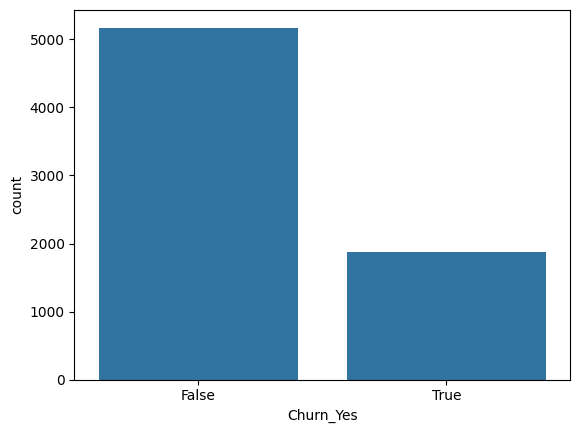

In [13]:
sns.countplot(x = 'Churn_Yes', data = df)
plt.show()

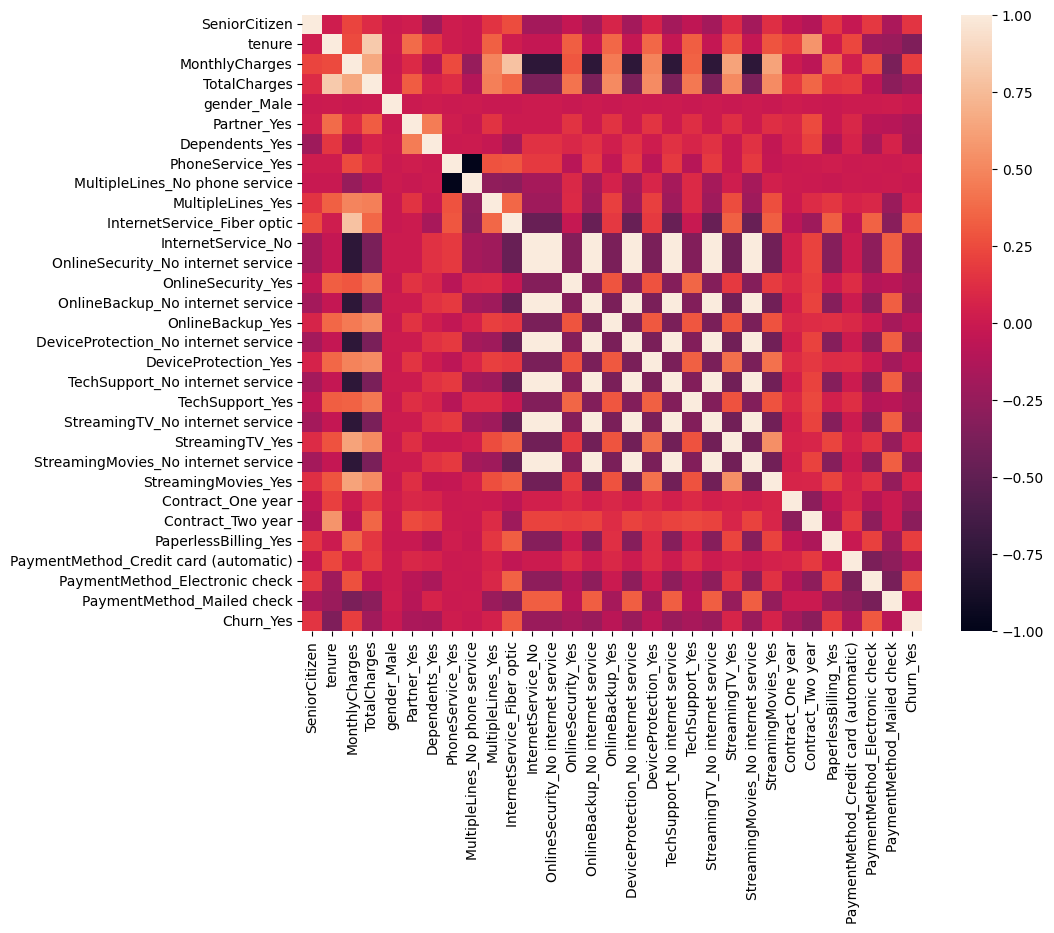

In [14]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr())
plt.show()

Machine Learning Model

In [15]:
x = df.drop("Churn_Yes", axis = 1)
y = df["Churn_Yes"]

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [18]:
y_pred = model.predict(x_test)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8218594748048261
[[934 102]
 [149 224]]
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



Customer Segmentation

In [20]:
df["Churn_Probability"] = model.predict_proba(x)[:,1]

In [21]:
conditions = [
    df["Churn_Probability"] > 0.7,
    df["Churn_Probability"] > 0.4
]

choices = ["At Risk", "Dormant"]
df["Segment"] = np.select(conditions, choices, default = "Loyal")
df["Segment"].value_counts()

,count
Segment,
Loyal,4934
Dormant,1683
At Risk,426


In [23]:
df["Segment"].value_counts(normalize=True) * 100


,proportion
Segment,
Loyal,70.055374
Dormant,23.896067
At Risk,6.048559


average monthly charges by segment


In [24]:
df.groupby("Segment")["MonthlyCharges"].mean()


,MonthlyCharges
Segment,
At Risk,83.421362
Dormant,77.019459
Loyal,58.969467


Average Tenure by Segment

In [25]:
df.groupby("Segment")["tenure"].mean()

,tenure
Segment,
At Risk,5.474178
Dormant,15.491979
Loyal,40.450953


At Risk customers have higher monthly charges and lower tenure.
Therefore, pricing and engagement strategies are recommended.

#Bussiness Recommendations

## Model Accuracy and Customer Segmentation

**The Logistic Regression model achieved an accuracy of:** 82.19%

**Customer Segmentation:**

*   **At Risk:** 6.05%
*   **Dormant:** 23.90%
*   **Loyal:** 70.05%

At Risk customers have higher monthly charges and lower tenure. Therefore, pricing and engagement strategies are recommended.

## Based on model predictions and customer segmentations:

### 1. At Risk Customers:
 There customers have high churn probability ( >70% ).
 #### Strategy:
 - Offer 10% discount on monthly charges
 - Provide annual contract conversion offers
 - offer freee technical support

 ### 2. Dormat Customers:
 Moderate churn probability (40 - 70%).

#### Strategy:
- Send promotional SMS/email campaings
- Offer bundled service packages

### 3. Loyal Customers:
Low churn probability (<40%).
#### Strategy:
- Provide loyalty rewards
- Referral bonus programs
- Premium membership offers

## Based on model predictions and customer segmentations:

### 1. At Risk Customers:
 There customers have high churn probability ( >70% ).
 #### Strategy:
 - Offer 10% discount on monthly charges
 - Provide annual contract conversion offers
 - offer freee technical support

 ### 2. Dormat Customers:
 Moderate churn probability (40 - 70%).

#### Strategy:
- Send promotional SMS/email campaings
- Offer bundled service packages

### 3. Loyal Customers:
Low churn probability (<40%).
#### Strategy:
- Provide loyalty rewards
- Referral bonus programs
- Premium membership offers